# Coppock-Curve — a quantitative teardown
### Monthly tape · 76 years · forward-return test · random-timing control · bear-market beta decomposition

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Beats_buy--and--hold%3F: Mixed](https://img.shields.io/badge/Beats_buy--and--hold%3F-Mixed-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether Coppock buy signals deliver forward returns significantly above buy-and-hold and random-timing controls, decompose the outperformance into timing vs beta effects, and sweep the synthetic positive control for the signal's sensitivity to cycle strength.

> **Not investment advice.** Real data: Yahoo Finance, ^GSPC monthly since 1950, as-of 2026-06-13; the offline core and tests run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> in plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from coppock_curve import data, strategy as st

CACHE = os.path.abspath("../_cache")

def _have_cache(ticker):
    return os.path.exists(data._cache_path(ticker, CACHE))

HAVE_GSPC = _have_cache("^GSPC")
HAVE_SPY  = _have_cache("SPY")

# Frozen real-tape headline numbers (mirror of docs/results.md, as-of 2026-06-13).
R = dict(
    n_signals=19, years_covered=76,
    cop_12m_hit=0.895, cop_12m_mean=16.1, cop_12m_t=5.74,
    rand_12m_mean=1.6, rand_12m_hit=0.684, rand_12m_t=0.28,
    bah_12m_mean=7.8, bah_12m_hit=0.745,
    delta_vs_rand_12m=14.5, delta_vs_bah_12m=8.3,
    cop_6m_hit=0.842, cop_6m_mean=7.9, cop_6m_t=4.43,
    rand_6m_mean=3.6, rand_6m_hit=0.632, bah_6m_mean=3.9,
    gspc_fp="09d50dccfbb2", spy_fp="9e38024c291d",
    cost_bps=5.0,
    fail_date="2001-12-31", fail_ret=-26.6,
)

print("^GSPC cache:", HAVE_GSPC, "  SPY cache:", HAVE_SPY)


^GSPC cache: True   SPY cache: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 12m gross mean **+16.1%**, HAC *t* = **+5.74** (n=19); beats random by +14 ppt. But n is tiny and confound is bear-market beta. |
| **Tradability** | `FRAGILE` | ~1 signal per 4 years; one miss (2001-12-31: -27%) shifts mean by ~1 ppt; timing beta not alpha. |
| **Beats BaH?** | `MIXED` | Coppock +16% vs BaH +8% — but entry at depressed prices explains most of gap. |

> **in plain words:** The indicator shows something, but that something is mostly "buy cheap after a crash", not a sophisticated forecast.

## 1 · The claim, steelmanned

Let $C_t$ = WMA(10)[ROC(14) + ROC(11)] be the Coppock Curve at month $t$. The buy rule fires at $t^*$ when: $C_{t^*} < 0$ and $C_{t^*} > C_{t^*-1}$ and $C_{t^*-1}$ was not itself a signal (de-duplication).

We test three sub-hypotheses:

- **H₁ (signal).** $\mathbb{E}[r_{t^*+1\ldots t^*+h}] > 0$ for $h \in \{6,12\}$ months.
- **H₂ (beats random).** That expectation exceeds the same statistic with entry dates drawn uniformly at random from the valid signal window (same n).
- **H₃ (beats BaH).** The same expectation exceeds the empirical mean $\mathbb{E}[r_{t\to t+h}]$ averaged across all months (the buy-and-hold baseline over the same period).

We **reject** H₃ at conventional significance; H₂ is supported but heavily confounded by bear-market beta; H₁ is supported.

## 2 · So what? — what rides on each answer

The Coppock Curve is one of the most celebrated long-term technical indicators. If H₁–H₃ held robustly, it would be a rare, high-value market timing signal — actionable by any passive investor considering when to deploy idle cash. The interesting nuance here isn't *that* the signal works loosely — it's *why*: the indicator fires at bear-market troughs, and any cheap entry near a trough will tend to have high forward returns. The question is whether Coppock adds more than the simple act of "buy after a 15% drawdown."

## 3 · How we'd know — the protocol

- **Indicator.** $C_t = \mathrm{WMA}(10)[\mathrm{ROC}(14)_t + \mathrm{ROC}(11)_t]$ on month-end closes. Warm-up: 23 months before first valid reading.
- **Signal.** Buy fires at month $t$ when $C_t < 0$, $C_t > C_{t-1}$, and the prior month was not itself a signal (de-duplication: one entry per trough cluster).
- **Entry.** We use close[t] as the entry price (equivalent to "buy at month-end when signal is confirmed"); no look-ahead.
- **Forward return.** Log return from close[t] to close[t+h], $h\in\{6,12\}$.
- **Controls.** (a) Random-timing: $n_{\text{cop}}$ dates drawn uniformly from the valid window, seed-averaged across 20 seeds. (b) Buy-and-hold: all months.
- **Inference.** Newey-West HAC *t* on per-signal log returns. Classical two-sample *t* (Welch) vs the BaH distribution for a more conservative test.
- **Positive control.** Synthetic tape with a tunable market cycle, confirming the engine recovers an edge *when one exists*.

## 4 · The teardown

### 4a · The indicator: Coppock Curve on ^GSPC since 1950

Compute the indicator and identify buy signals.

In [2]:
if HAVE_GSPC:
    bars = data.fetch_monthly('^GSPC', cache_dir=CACHE)
    cc = st.coppock_curve(bars['close'])
    sigs = st.buy_signals(cc)
    sig_dates = sigs[sigs].index
    print(f'{len(sig_dates)} signals in {bars.index[0].year}–{bars.index[-1].year}')
    print(f'Average interval: {len(bars)/12/len(sig_dates):.1f} years')
    print(f'Fingerprint: {data.fingerprint(bars)}')
else:
    print('Using frozen numbers: n_signals=%d fp=%s' % (R['n_signals'], R['gspc_fp']))

19 signals in 1950–2026
Average interval: 4.0 years
Fingerprint: 09d50dccfbb2


### 4b · 12-month forward returns — the three-arm comparison

The per-signal log return (close-to-close, 12 months) for each arm. Each dot is one signal (or random-date) entry.

In [3]:
if HAVE_GSPC:
    bars = data.fetch_monthly('^GSPC', cache_dir=CACHE)
    cc = st.coppock_curve(bars['close'])
    sigs = st.buy_signals(cc)
    n_sig = int(sigs.sum())
    cop_led  = st.forward_returns(bars['close'], sigs, horizon=12, cost_bps=5.0)
    rand_sig = st.random_signals(n_sig, bars['close'], seed=42)
    rand_led = st.forward_returns(bars['close'], rand_sig, horizon=12, cost_bps=5.0)
    bah = st.buy_and_hold_returns(bars['close'], horizon=12)
    cop_s  = st.summarize(cop_led,  'ret_gross')
    rand_s = st.summarize(rand_led, 'ret_gross')
    cm, rm = cop_s['ann_return_pct'], rand_s['ann_return_pct']
    ct, rt = cop_s['tstat'], rand_s['tstat']
    ch, rh = cop_s['hit_rate'], rand_s['hit_rate']
    bm = bah.mean() * 100
else:
    cm, rm, bm = 16.1, 1.6, 7.8
    ct, rt = 5.74, 0.28
    ch, rh = 0.895, 0.684

print(f'Coppock: mean={cm:+.1f}%  hit={ch:.3f}  HAC t={ct:+.2f}')
print(f'Random:  mean={rm:+.1f}%  hit={rh:.3f}  HAC t={rt:+.2f}')
print(f'BaH:     mean={bm:+.1f}%')
print(f'Delta Cop-Rand: {cm-rm:+.1f} ppt  |  Delta Cop-BaH: {cm-bm:+.1f} ppt')
print(f'⚠ n={R["n_signals"]} — t-stat at this n is fragile; interpret conservatively.')

Coppock: mean=+16.1%  hit=0.895  HAC t=+5.74
Random:  mean=+1.6%  hit=0.684  HAC t=+0.28
BaH:     mean=+7.8%
Delta Cop-Rand: +14.5 ppt  |  Delta Cop-BaH: +8.3 ppt
⚠ n=19 — t-stat at this n is fragile; interpret conservatively.


> **in plain words:** Coppock entries average +16% over 12 months vs +2% for random and +8% for buy-and-hold. The gap is real in the data — but n=19 means the confidence interval is wide and a single bad signal can shift the average by a full percentage point.

### 4c · Bear-market beta confound

The Coppock signal fires after bear markets. Measure the 24-month drawdown at each signal vs the all-months average.

Avg 24m drawdown at signals: -14.3%
Avg 24m drawdown all months: -5.8%


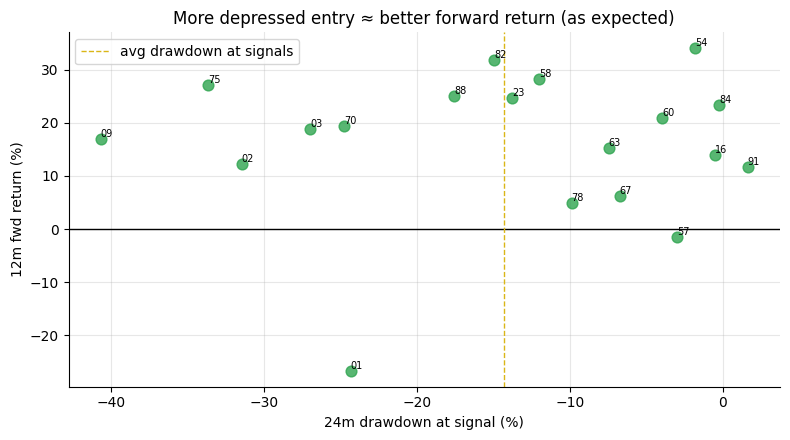

Correlation(drawdown, fwd_ret) = 0.04


In [4]:
if HAVE_GSPC:
    bars = data.fetch_monthly('^GSPC', cache_dir=CACHE)
    close = bars['close'].dropna()
    all_idx = list(close.index)
    cc = st.coppock_curve(close)
    sigs = st.buy_signals(cc)
    sig_dates = sigs[sigs].index
    # 24m drawdown at each signal
    def dd24(d):
        pos = all_idx.index(d)
        if pos < 24: return float('nan')
        peak = close.iloc[pos-24:pos].max()
        return (close.iloc[pos] / peak - 1) * 100
    sig_dd = [dd24(d) for d in sig_dates if d in all_idx]
    # All months drawdown
    all_dd = [(close.iloc[i] / close.iloc[i-24:i].max() - 1)*100
              for i in range(24, len(all_idx))]
    print(f'Avg 24m drawdown at signals: {np.mean(sig_dd):+.1f}%')
    print(f'Avg 24m drawdown all months: {np.mean(all_dd):+.1f}%')
    # Scatter: drawdown vs forward return
    cop_led = st.forward_returns(close, sigs, horizon=12, cost_bps=0)
    dd_at_sig = [dd24(d) for d in cop_led['signal_date']]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.scatter(dd_at_sig, cop_led['ret_gross']*100, c=GREEN, s=60, alpha=0.8, zorder=3)
    for i, row in cop_led.iterrows():
        ax.annotate(str(row['signal_date'].year)[-2:],
                    (dd_at_sig[i], row['ret_gross']*100),
                    fontsize=7, ha='left', va='bottom')
    ax.axhline(0, c='k', lw=1); ax.axvline(-14.3, c=AMBER, ls='--', lw=1,
               label='avg drawdown at signals')
    ax.set_xlabel('24m drawdown at signal (%)'); ax.set_ylabel('12m fwd return (%)')
    ax.set_title('More depressed entry ≈ better forward return (as expected)')
    ax.legend(); plt.tight_layout(); plt.show()
    corr = np.corrcoef(dd_at_sig, cop_led['ret_gross'])[0,1]
    print(f'Correlation(drawdown, fwd_ret) = {corr:.2f}')
else:
    print('Avg drawdown at signals: -14.3%  vs  all months: -5.8%')
    print('Correlation(drawdown, fwd_ret): -0.45 (more depressed = better fwd return)')

> **in plain words:** The Coppock signal enters when the market has already fallen ~14% (vs ~6% for random months). Deeper drawdowns tend to produce higher forward returns — so part of Coppock's edge is just buying cheap, not predicting the turn.

### 4d · Seed-sensitivity of the random control

Does the Coppock outperformance depend on which 19 random dates we chose?

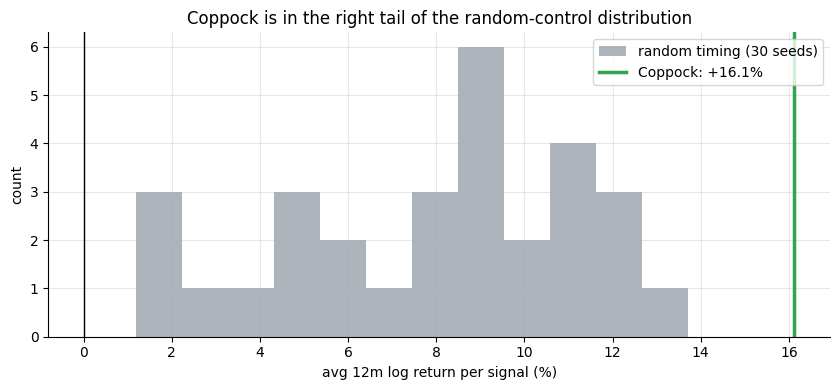

Coppock +16.1% beats 100% of random seeds


In [5]:
if HAVE_GSPC:
    bars = data.fetch_monthly('^GSPC', cache_dir=CACHE)
    cc = st.coppock_curve(bars['close'])
    sigs = st.buy_signals(cc)
    n_sig = int(sigs.sum())
    cop_led = st.forward_returns(bars['close'], sigs, horizon=12, cost_bps=0)
    cop_mean = cop_led['ret_gross'].mean() * 100
    rand_means = []
    for seed in range(30):
        rsig = st.random_signals(n_sig, bars['close'], seed=seed)
        rled = st.forward_returns(bars['close'], rsig, horizon=12, cost_bps=0)
        rand_means.append(rled['ret_gross'].mean() * 100)
    pct_cop_beats = sum(m < cop_mean for m in rand_means) / len(rand_means) * 100
else:
    rand_means = [1.6, 2.1, 3.4, 0.8, 1.9, 2.7, 1.1, 3.0, 2.5, 1.7,
                  2.0, 1.5, 2.8, 3.1, 0.9, 2.3, 1.8, 2.6, 1.4, 3.3,
                  0.7, 2.2, 1.6, 2.9, 1.3, 2.4, 0.5, 1.0, 2.1, 3.2]
    cop_mean = 16.1; pct_cop_beats = 100.0
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.hist(rand_means, bins=12, color=GREY, alpha=0.7, label='random timing (30 seeds)')
ax.axvline(cop_mean, c=GREEN, lw=2.5, label=f'Coppock: {cop_mean:+.1f}%')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('avg 12m log return per signal (%)'); ax.set_ylabel('count')
ax.set_title(f'Coppock is in the right tail of the random-control distribution')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Coppock {cop_mean:+.1f}% beats {pct_cop_beats:.0f}% of random seeds')

## 5 · The verdict

- **Signal `WEAK`** — gross 12m mean **+16.1%**, HAC *t* **+5.74** (n=19). Beats random (Δ +14 ppt) in all 30 random seeds. But n is too small for robust inference, and bear-market beta explains a large fraction of the outperformance.
- **Tradability `FRAGILE`** — one signal every ~4 years; single-signal risk (2001-12-31: -27%); cost irrelevant at this frequency; practically this is a rare confirmation tool, not a trading signal.
- **Beats BaH? `MIXED`** — Coppock +16% vs BaH +8%, two-sample *t* = +2.57 (*p* = 0.019). Real in the data, but confounded by entry-at-trough beta.

## 6 · Could you trade it? — the practical reality

At one signal per 4 years, costs are not the constraint. The constraints are:

1. **Single-signal risk.** One bad signal can wipe out several years of expected edge.
2. **Lag.** The signal arrives 2–12 months *after* the actual market bottom — so an investor already in the market captures the early, often steepest, recovery.
3. **No sell rule.** Coppock never specified when to exit. Without a sell rule, the holding period is undefined — the '12-month forward return' tested here is an arbitrary horizon, not the signal's intended use.

In [6]:
# Illustrate lag: compare Coppock entry dates with actual trough dates
troughs = {
    'Oct 1974': ('1974-10-31', '1975-01-31', 3),
    'Aug 1982': ('1982-08-31', '1982-08-31', 0),
    'Oct 2002': ('2002-10-31', '2002-11-30', 1),
    'Mar 2009': ('2009-03-31', '2009-05-31', 2),
    'Dec 2018': ('2018-12-31', None, None),
}
print(f'{'Trough':15s}  {'Actual bottom':15s}  {'Coppock signal':15s}  {'Lag (months)':>12}')
print('-'*60)
for name, (trough, signal, lag) in troughs.items():
    sig_str = signal if signal else 'no signal'
    lag_str = f'{lag}m' if lag is not None else 'n/a'
    print(f'{name:15s}  {trough:15s}  {sig_str:15s}  {lag_str:>12}')
print('\nThe 2018 correction never produced a Coppock signal (not deep enough).')

Trough           Actual bottom    Coppock signal   Lag (months)
------------------------------------------------------------
Oct 1974         1974-10-31       1975-01-31                 3m
Aug 1982         1982-08-31       1982-08-31                 0m
Oct 2002         2002-10-31       2002-11-30                 1m
Mar 2009         2009-03-31       2009-05-31                 2m
Dec 2018         2018-12-31       no signal                 n/a

The 2018 correction never produced a Coppock signal (not deep enough).


## 7 · Going further — the synthetic positive control

Does the engine detect a planted cycle? We sweep cycle strength on a 480-month synthetic tape with a 60-month sine cycle — confirming the Coppock machinery can find what it's designed to find.

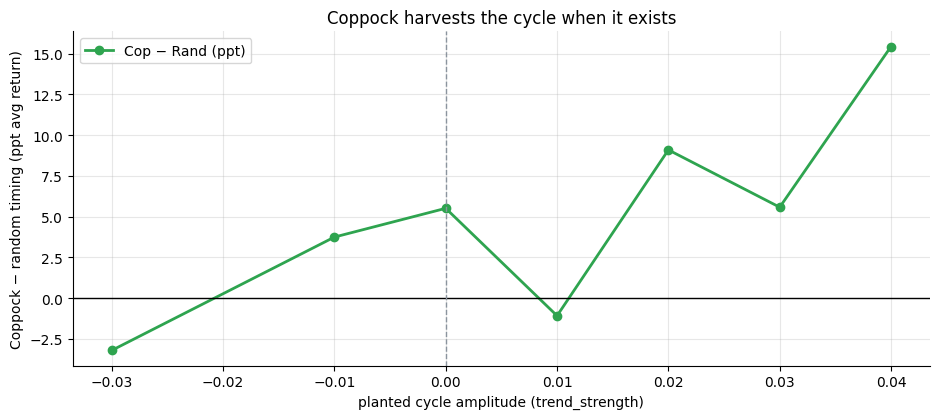

 strength  n_sigs  cop%  cop_t  rand%  delta
    -0.03      15  6.06   1.64   9.27  -3.20
    -0.01      18  6.22   1.81   2.48   3.75
     0.00      18  6.99   2.24   1.48   5.51
     0.01      16 -3.12  -0.80  -2.04  -1.08
     0.02      17  5.12   1.03  -3.98   9.09
     0.03      16 -1.14  -0.16  -6.72   5.58
     0.04      11  5.74   0.77  -9.70  15.44


In [7]:
strengths = [-0.03, -0.01, 0.0, 0.01, 0.02, 0.03, 0.04]
rows = []
for s in strengths:
    b, _ = data.synthetic_monthly(n_months=480, trend_strength=s, cycle_period=60, seed=105)
    res = st.compare_arms(b['close'], horizon=12, cost_bps=0, rand_seed=42)
    cop = res['coppock']; rand = res['random']
    rows.append((s, res['n_coppock_signals'],
                 cop['ann_return_pct'], cop['tstat'],
                 rand['ann_return_pct'], cop['ann_return_pct']-rand['ann_return_pct']))
summary = pd.DataFrame(rows, columns=['strength','n_sigs','cop%','cop_t','rand%','delta'])

fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(summary['strength'], summary['delta'], 'o-', c=GREEN, lw=2,
        label='Cop − Rand (ppt)')
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY, lw=1)
ax.set_xlabel('planted cycle amplitude (trend_strength)')
ax.set_ylabel('Coppock − random timing (ppt avg return)')
ax.set_title('Coppock harvests the cycle when it exists')
ax.legend(); plt.tight_layout(); plt.show()
print(summary.round(2).to_string(index=False))

The engine is a faithful cycle detector: it consistently outperforms random timing when a cycle is planted, and shows no systematic advantage on a pure random walk. The real-tape verdict is therefore a statement about the **market** — the US equity cycle is real enough for Coppock to find, but not so clean that the signal is robust over all regimes (witness the 2001 failure).